# RoboMaster

For these activities, we are going to use the [RoboMaster robot by DJI](https://www.dji.com/ch/products/steam).

## 1. Meet the robot

The RoboMaster is a four-wheeled, modular robot. We will use it in the configuration depicted below. 

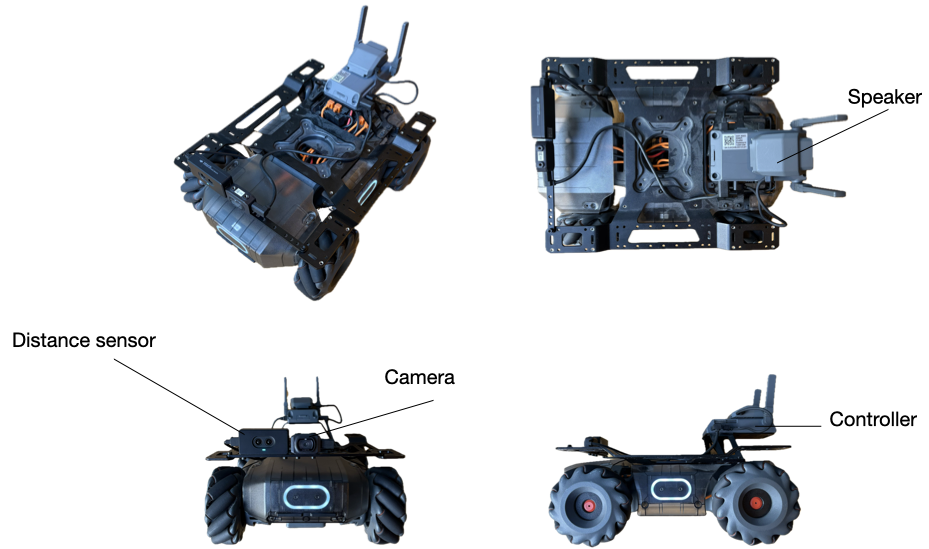

In [1]:
from IPython.display import Image

Image(filename='robomaster.png') 

- **Wheels**: Four Mecanum wheels that let the robot move onmindirectionally
- **Camera**: Front-facing camera
- **Distance sensor**: Front-facing sensor that measures the distance to the nearest obstacle
- **LEDs**: Four oval-shaped RGB LEDs on the sides
- **Speaker**: Top-mounted speaker
- **Controller**: Computer board to which users connect via WiFi to control the robot.

## 2. Python client

The robot can be controlled through a [Python client](https://robomaster-dev.readthedocs.io/en/latest/), which communicate with the robot's controller via WiFi.

<div class="alert alert-block alert-info">
<b>Install the client</b> 

Install the following Python packages in a virtual environment (Python 3.11--3.14).

```
pip install git+https://github.com/jeguzzi/RoboMaster-SDK.git
pip install -i https://test.pypi.org/simple/ rm-libmedia-codec
```

Check that the package was indeed installed: the following command should return no error.

```
python -c "from robomaster import robot"
```
</div>

We will progressively explain the client API when we need it.

## 3. Simulation

Before playing with the real robots, we will controll robots simulated with [CoppeliaSim](https://www.coppeliarobotics.com).
The simulated and real robots expose the same interface to the Python client.

Each group will work with a different robot, identified by a serial number. For real robots, the serial number is reported on top of the controller, while simulated robots have serial numbers "1", "2", "3", ..., where group #1 will work with robot "1" and so on.

<div class="alert alert-block alert-info">
<b>Visualize the simulation</b> 
Access the simulation from a browser by connecting to <code>http://SIMULATOR_IP:GROUP_PORT</code>, where <code>GROUP_PORT</code> is 10001 for group #1, 10002 for group #2 and so on.
</div>

<div class="alert alert-block alert-info">
<b>Visualize the simulation inside the notebook</b> 
In the next cell, use <a href="https://ipython.readthedocs.io/en/stable/api/generated/IPython.display.html#IPython.display.IFrame">IPython.display.IFrame</a>
to visualize the simulation inside the notebook.
</div>

In [51]:
# TBC: Visualize the simulation inside the notebook

To control a robot, we instantiate `Robot` and select a serial number by specifying argument `sn`:

```python
from robomaster.robot import Robot

robot = Robot()
robot.initialize(conn_type="sta", sn=...)
```

when done, we close the client:

```python
robot.close()
```

<div class="alert alert-block alert-warning">
<b>Write self contained controllers</b> 
    
Better to let controllers be contained in single notebook cells to avoid leaving clients dangled when the robot (real or simulated) restart. 
</div>

Each controller should therefore by encapsulated like

```python
robot = Robot()
robot.initialize(conn_type="sta", sn=...)
...
robot.close()
```

<div class="alert alert-block alert-info">
<b>Connect to the simulated robot</b> 
    
Check that `Robot.initialize` returns `True`.
</div>

In [52]:
# TBC: Connect to the simulated robot

## 4. LEDs

To control LEDs, use [robot.led.set_led(...)](https://robomaster-dev.readthedocs.io/en/latest/python_sdk/robomaster.html#module-robomaster.led):

```python
def set_led(comp=Literal["all", "bottom_front", "bottom_back",
                         "bottom_left", "bottom_right"] = "all", 
            r: int = 0, 
            g: int = 0, 
            b: int = 0, 
            effect=Literal["on", "off", "breath"] = "on",
            freq: int = 1) -> bool: ...
```

<div class="alert alert-block alert-info">
<b>Light up all LEDs to red</b> 
</div>

In [53]:
# TBC: Light up LEDs to red

<div class="alert alert-block alert-info">
<b>Implement a LED pattern</b>
    
like, for instance, the blue-red-blue-red-... pattern used by emergency vehicles.
</br><i>TIP:</i> use <code>time.sleep(...)</code>
</div>

In [54]:
# TBC: LED pattern

## 5. Motion

The four Mecanum wheels of the robot allows it to move in each direction and to rotate independently of translation.

<div class="alert alert-block alert-info">
<b>Explore the kinematics</b>

Gently push the real robot and observe how the wheels react.
In short, you are going to control how fast each wheel spins. How should they spin to make the robot 
<ol>
    <li>move forwards?</li>
    <li>move rightwards?</li>
    <li>rotate in place clockwise?</li>
    <li>rotate in place counter-clockwise?</li>
</ol>
</div>

### Control wheel speeds

Let us transfer what we learned to control the wheel speeds using [robot.chassis.drive_wheels(...)](https://robomaster-dev.readthedocs.io/en/latest/python_sdk/robomaster.html#robomaster-chassis):

```python
def drive_wheels(w1: int = 0, 
                 w2: int = 0, 
                 w3: int = 0, 
                 w4: int = 0, 
                 timeout: float | None = None) -> bool: ...
```

<div class="alert alert-block alert-info">
<b>Control wheel speeds</b>
<ul>
<li>Advance forwards at a speed of 0.5 m/s</li>
<li>Advance forwards at a speed of 0.5 m/s and stop after 2 m</li>
<li>Move laterally (towards right) at a speed of 0.5 m/s</li>
<li>Rotate in place clockwise or counterclockwise</li>
<li>Predict what happens when the left wheels rotate forwards at 5 RPM, the right wheels rotate forwards at 6 RPM, then try running it</li>
</ul>
<i>TIP:</i> measure the real robot wheel radius
</div>

In [55]:
# TBC: wheel speeds controllers

### Velocity estimation

The robots estimates its linear and angular velocities.
Interested clients can subscribe to this kind of information by specifying a callback called each time new data is available.

To start getting updates on velocity estimations, call [robot.chassis.sub_velocity](https://robomaster-dev.readthedocs.io/en/latest/python_sdk/robomaster.html#robomaster-chassis) 
```python
def sub_velocity(freq: int = Literal[1, 5, 10, 20, 50], 
                 callback: Callable[[tuple[float, float, float, float, float, float], None] | None = None): ...
```
that will publish velocity estimations as tuples of 6 numbers.

To stop getting updates, call [robot.chassis.unsub_velocity](https://robomaster-dev.readthedocs.io/en/latest/python_sdk/robomaster.html#robomaster-chassis)
```python
def unsub_velocity(): ...
```

The callback, in this case, receives a tuple $(v_x, v_y, v_z, v_{bx}, v_{by}, v_{bz})$ where x is oriented forwards, y rightwards, and z upwards. The first three the x-y-z components in a world-fixed reference frame, the last three the x-y-z components in the robot's reference frame.

For example, to print the linear speed in the robot frame, we can define a callback like

```python
    def cb(data):
        print(f'forwards: {data[3]}, rightwards: {data[4]}')
```
and start a subscription (at 5Hz) 
```python
    robot.chassis.sub_velocity(freq=5, callback=cb)
```
before stopping it after some time
```python
    # wait some time
    time.sleep(5)
    robot.chassis.unsub_velocity()
```

Data for angular velocities is available through [robot.chassis.sub_imu](https://robomaster-dev.readthedocs.io/en/latest/python_sdk/robomaster.html#robomaster-chassis), which also provides a tuple of 6 numbers, the last of which is the clock-wise angular speed in degrees per second.

<div class="alert alert-block alert-info">
<b>Control wheel speeds (2)</b>
    
Modify the controller to verify that the robot is indeed moving at the selected velocities (printing them would be enough).
</div>



In [56]:
# TBC: wheel speeds controllers with velocity checks

### Control velocities

The robot implements a controller that accept target linear and angular velocity, exposed thought [robot.chassis.drive_speed](https://robomaster-dev.readthedocs.io/en/latest/python_sdk/robomaster.html#robomaster-chassis):

```python
def drive_speed(x: float = 0.0, 
                y: float = 0.0, 
                z: float = 0.0, 
                timeout: float | None = None) -> bool: ...
```

<div class="alert alert-block alert-info">
<b>Control velocity</b>

Use it to write three controllers that:
<ol>
    <li>Rotate in place exactly 360 degrees in 5 seconds, then stop and light up the robot LEDs in red.</li>
    <li>Follow a square with an edge of 2m in 20 seconds, then stop and light up the robot LEDs in blue. The robot should always point in the direction it is moving, or rotate in place.</li>
    <li>Follow a circle while looking at the center of the circle, in 10 seconds.</li>
</ol>
</div>

In [57]:
# TBC: one full rotation

In [58]:
# TBC: square

In [59]:
# TBC: circle

### Control target poses

The robot also implements a controller that accept target poses, exposed thought [robot.chassis.move](https://robomaster-dev.readthedocs.io/en/latest/python_sdk/robomaster.html#robomaster-chassis).

```python
def move(x: float = 0, 
         y: float = 0, 
         z: float = 0, 
         xy_speed: float = 0.5, 
         z_speed: float = 30) -> AwaitableAction: ...
```

The resulting action can be *awaited*, i.e., we can wait while the robot reaches the target:

```python
robot.chassis.move(x=1).wait_for_completed()
```

<div class="alert alert-block alert-info">
<b>Control targets</b>

Read the docs of `move` and use it to reach a set of 5 waypoints decided by you.
</div>


In [60]:
# TBC: 5 waypoints path

## Camera


To be able to capture a frame, we have to start the video stream from the robot camera to the Python client using [robot.camera.start_video_stream](https://robomaster-dev.readthedocs.io/en/latest/python_sdk/robomaster.html#module-robomaster.camera):
```python
def start_video_stream(
        display: bool = True, 
        resolution: Literal["360p", "540p", "720p"] = "720p"
    ) -> bool: ...
```

<div class="alert alert-block alert-warning">
<b>Use display=False</b> 
    
Do not display the frame when running in a notebook.
</div>

Received frames are stored in a FIFO queue. We can read the first BGR frame (`strategy="pipeline"`) in the queue or the latest received (`strategy="newest"`) using [robot.camera.read_video_frame](https://robomaster-dev.readthedocs.io/en/latest/python_sdk/robomaster.html#module-robomaster.camera):
```python
def read_video_frame(
        timeout: float = 3, 
        strategy: Literal["pipeline", "newest"] = "pipeline"
    ) -> numpy.ndarray | None:
```
The call blocks until a frame is available or the timeout passes, in which case it returns `None`.

We should stop the video stream once done using [robot.camera.stop_video_stream](https://robomaster-dev.readthedocs.io/en/latest/python_sdk/robomaster.html#module-robomaster.camera)::

```python
def stop_video_stream()-> bool: ...
```

For instance, to capture 10 frames, we can run:
```python
    frames = []
    robot.camera.start_video_stream(display=False)
    while len(frames) < 10:
        frame = robot.camera.read_video_frame()
        if frame is not None:
            frames.append(frame)
    robot.camera.stop_video_stream()
```

<div class="alert alert-block alert-info">
<b>Visualize a frame</b>

Take and visualize an image with `matplotlib.pyplot.imshow`. Make sure the colors are correct.
</div>

In [61]:
#TBC: Visualize a frame

<div class="alert alert-block alert-info">
<b>Capture an object</b>

Save a set of pictures of an object while the robot orbits around it. Approximately one picture every 5 degrees.  Extra: annotate each picture with the corresponding robot orientation you can get from <code>robot.chassis.sub_attitude</code>.
</div>

In [62]:
#TBC: Capture a frame

<div class="alert alert-block alert-info">
<b>Detect a ball</b>

Assume that the ball is the only red object in the world. Take a few pictures of the ball and save them. Design a function that given a picture returns the mask of the pixels belonging to the ball (use thresholds on BGR, or on the hue and saturation components, computed using [skimage.color.rgb2hsv](https://scikit-image.org/docs/stable/api/skimage.color.html#skimage.color.rgb2hsv))
</div>

In [63]:
#TBC: Detect a ball (segmentation)

<div class="alert alert-block alert-info">
<b>Detect a ball (2)</b>

Design and test a function that uses the previous function and returns the centroid and number of pixels of the largest connected component (see <a href="https://scikit-image.org/docs/stable/api/skimage.measure.html#skimage.measure.regionprops">skimage.measure.regionprops</a>).
</div>                                                                     

In [64]:
#TBC: Detect a ball (centroid)

## Vision-based control

<div class="alert alert-block alert-info">
<b>Point towards a ball</b>

Given a world with a ball, assume the ball is already visible, and rotate in place towards the ball and keep pointing at the ball even if it moves (TIP: use a P controller)

Extension: if the ball is not visible, rotate very slowly in a random direction until the ball comes into view
</div> 


<div class="alert alert-block alert-info">
<b>Reach a ball</b>

Move in a direction such that the size of the ball in the image is X pixels. Also here it makes sense to use a P controller
Determine X if I want the distance to be 40 cm
</div> 

To debug perception, it is useful to move around the robot by pushing it while acquiring the video stream. When a client connect, the robot will engage the wheels motors, resisting pushes. To disengage the wheel, call `robot.chassis._set_mode(False)`:

```python
def _set_mode(value: bool) -> None: ...
```

Call `robot.chassis._set_mode(True)` when you need to control the wheel motors again. 

Pay attention to set the correct (real) robot serial number in `robot.initialize(conn_type="sta", sn=...)`

<div class="alert alert-block alert-info">
<b>Video</b>

Make a video acquired by the moving robot (with unengaged wheels) with the bounding box and centroid of the detected connected component overlayed to the image. Use matplotlib and plt.savefig.
</div> 



In [65]:
# TBC: make video from real robot

You are now ready to test the controllers on the real-robot.

At first, you will need to tune the perception pipeline on a few pictures of the real ball acquired by the real robot. 
At first use a low enough speed that the robot keep safe even if the control fails (i.e., you can stop it before it hits an obstacle). 


<div class="alert alert-block alert-info">
<b>Tune and test the controllers on the real robot</b>

Test the two previous controllers ("point" and "reach"), starting with "point" (which is safer, as the robots just rotate it place).
</div> 

Now you are ready to assemple a more complex controller:

<div class="alert alert-block alert-info">
<b>Complex controller</b>

Initially in simulation and then, once it works, on the real robot, design and test the following controller:
<ol>
    <li>State 1: The robot looks for the ball rotating slowly </li>
    <li>State 2: When it finds the ball, it keeps it into view and moves at a distance of 40cm from it</li>
    <li>State 3: The robot starts making a full rotation around the ball always looking at it, taking one picture of the ball every 10 degrees of rotation</li>
    <li>State 4: The robot has finished taking the pictures, is happy and makes a little dance</li>
</ol>
Show each state with a separate color of the LEDs.
</div> 

##  Distance sensor

To get distance readings from the front-facing sensor, we start a subscriber using [robot.sensor.sub_distance](https://robomaster-dev.readthedocs.io/en/latest/python_sdk/robomaster.html#module-robomaster.sensor)
```python
def sub_distance(
    freq: int = Literal[1, 5, 10, 20, 50], 
    callback: Callable[[tuple[float, float, float, float], None] | None = None
    ) -> bool : ...
```
which we eventually stop with [robot.sensor.unsub_distance](https://robomaster-dev.readthedocs.io/en/latest/python_sdk/robomaster.html#module-robomaster.sensor)

```python
def unsub_distance(): ...
```

The callback receives a tuple of 4 numbers, the first being the distance read by the sensor in mm.
A value of `65534` denotes no detection within the range of view.

For example, to store the last N readings in a circular buffer, we can use a callback like

```python
readings = queue.Queue(maxsize=50)

def cb(data):
    while readings.full():
        readings.get_nowait()
    readings.put(data[0])

robot.sensor.sub_distance(freq=10, callback=cb)
```


<div class="alert alert-block alert-info">
<b>Plot the readings</b>

Let the robot rotate in place while placing an object in front of it. Plot the distance readings over at least a full rotation.
</div> 

In [66]:
# TBC: plot readings

<div class="alert alert-block alert-info">
<b>Find the sensor range</b>

Design and perform an experiment to find the maximal range of the sensor.
</div> 

In [67]:
# TBC: max range

<div class="alert alert-block alert-info">
<b>Turn towards near object</b>

Write a simple controller such that: the robot slowly rotates in place. As soon as it sees an object that is less than 1m far, it lights up red and stops.
</div> 

In [68]:
# TBC: turn towards near object